# 📊 Creator Cluster Analysis
## Luồng 2 · Luồng 3 · Luồng 5

| Luồng | Câu hỏi trung tâm |
|---|---|
| **2 — Hồ sơ định danh** | Cụm này là ai, điểm mù của họ là gì? |
| **3 — Kính lúp thương mại** | Nên chọn ai cho mục tiêu campaign cụ thể? |
| **5 — Dự báo hành trình** | 6 tháng nữa ai sẽ thắng? |

---

In [19]:
# ============================================================
# 0.1 — IMPORTS & PLOT SETTINGS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
})
sns.set_palette('husl')

CLUSTER_COL = 'cluster_kmeans'   # ← đổi tên cột cluster nếu khác

print('✅ Imports OK')

✅ Imports OK


In [20]:
# ============================================================
# 0.2 — COLUMN DEFINITIONS
# ============================================================
SIZE_COLS      = ['followerCnt', 'startingRate100k', 'recommendRate100k']
RANK_COLS      = ['followersGrowthRateRank', 'avgSixSecondsViewsRateRank',
                  'medianViewsRank', 'videoCompleteRateRank', 'engagementRateRank']
BENCHMARK_COLS = ['avgSixSecondsViewsBenchMarkViews', 'medianBenchMarkViews', 'engagementRateBenchMark']
PERF_COLS      = ['followersGrowthRate', 'avgSixSecondsViewsRate', 'videoCompleteRate',
                  'engagementRate', 'medianViews', 'broadcastingScore',
                  'collaborationScore', 'commercialScore']
AUDIENCE_COLS  = ['active_active', 'active_inactive',
                  'age_18-24', 'age_25-34', 'age_13-17', 'age_35-44', 'age_55+', 'age_45-54', 'age_Other',
                  'device_APPLE', 'device_SAMSUNG', 'device_OPPO', 'device_XIAOMI', 'device_VIVO', 'device_Other',
                  'gender_Female', 'gender_Male',
                  'country_VN', 'country_US', 'country_JP', 'country_TW', 'country_KR',
                  'country_MM', 'country_KH', 'country_TH', 'country_PH', 'country_ID']
CONTENT_COLS   = ['Beauty', 'Education', 'Entertainment', 'Food', 'Sports']
RECENT_COLS    = ['total_views_recent', 'total_hearts_recent', 'total_comments_recent',
                  'median_view_recent', 'max_view_recent', 'cov_view_recent',
                  'burstiness_recent', 'recency_days_recent']

# Màu cho từng cluster (tối đa 8 clusters)
PALETTE = ['#E63946','#457B9D','#2A9D8F','#E9C46A','#F4A261','#6A0572','#1D3557','#A8DADC']

print('✅ Columns defined')

✅ Columns defined


In [21]:
# ============================================================
# 0.3 — LOAD DATA
# ============================================================
df = pd.read_csv('data_insights.csv') 

# ── DEMO DATA (xóa block này khi dùng data thật) ─────────────
'''
np.random.seed(42)
N, K = 600, 5

def make_cluster(n, seed, params):
    np.random.seed(seed)
    return {k: np.random.normal(mu, sd, n) for k, (mu, sd) in params.items()}

cluster_params = {
    0: dict(followerCnt=(8e4,3e4), engagementRate=(0.12,0.03), videoCompleteRate=(0.35,0.08),
            broadcastingScore=(75,10), commercialScore=(30,12), followersGrowthRate=(0.005,0.01)),
    1: dict(followerCnt=(2e4,8e3), engagementRate=(0.07,0.02), videoCompleteRate=(0.55,0.1),
            broadcastingScore=(60,12), commercialScore=(65,15), followersGrowthRate=(0.015,0.02)),
    2: dict(followerCnt=(5e4,2e4), engagementRate=(0.09,0.025), videoCompleteRate=(0.45,0.09),
            broadcastingScore=(50,15), commercialScore=(50,15), followersGrowthRate=(0.020,0.03)),
    3: dict(followerCnt=(1.5e4,5e3), engagementRate=(0.15,0.04), videoCompleteRate=(0.65,0.1),
            broadcastingScore=(80,8),  commercialScore=(25,10), followersGrowthRate=(0.040,0.04)),
    4: dict(followerCnt=(6e4,2.5e4), engagementRate=(0.05,0.02), videoCompleteRate=(0.28,0.07),
            broadcastingScore=(40,15), commercialScore=(45,18), followersGrowthRate=(0.002,0.005)),
}

dfs = []
for cid, params in cluster_params.items():
    n = N // K
    np.random.seed(cid * 100)
    d = pd.DataFrame({
        CLUSTER_COL: cid,
        'followerCnt':          np.abs(np.random.normal(params['followerCnt'][0], params['followerCnt'][1], n)),
        'startingRate100k':     np.abs(np.random.normal(500 + cid*80, 150, n)),
        'recommendRate100k':    np.abs(np.random.normal(480 + cid*60, 120, n)),
        'followersGrowthRate':  np.random.normal(params['followersGrowthRate'][0], params['followersGrowthRate'][1], n),
        'avgSixSecondsViewsRate': np.clip(np.random.normal(0.45 + cid*0.02, 0.1, n), 0.05, 1),
        'videoCompleteRate':    np.clip(np.random.normal(params['videoCompleteRate'][0], params['videoCompleteRate'][1], n), 0.05, 1),
        'engagementRate':       np.clip(np.random.normal(params['engagementRate'][0], params['engagementRate'][1], n), 0.005, 0.5),
        'medianViews':          np.abs(np.random.lognormal(8 + cid*0.2, 1, n)),
        'broadcastingScore':    np.clip(np.random.normal(params['broadcastingScore'][0], params['broadcastingScore'][1], n), 0, 100),
        'collaborationScore':   np.clip(np.random.normal(50 + cid*5, 15, n), 0, 100),
        'commercialScore':      np.clip(np.random.normal(params['commercialScore'][0], params['commercialScore'][1], n), 0, 100),
        'avgSixSecondsViewsBenchMarkViews': np.abs(np.random.lognormal(7.5, 0.8, n)),
        'medianBenchMarkViews': np.abs(np.random.lognormal(8, 0.8, n)),
        'engagementRateBenchMark': np.clip(np.random.normal(0.08, 0.02, n), 0.01, 0.3),
        'followersGrowthRateRank':      np.random.uniform(0.1, 0.9, n),
        'avgSixSecondsViewsRateRank':   np.random.uniform(0.1, 0.9, n),
        'medianViewsRank':              np.random.uniform(0.1, 0.9, n),
        'videoCompleteRateRank':        np.random.uniform(0.1, 0.9, n),
        'engagementRateRank':           np.random.uniform(0.1, 0.9, n),
        'active_active':    np.clip(np.random.normal(0.6 - cid*0.04, 0.1, n), 0.1, 1),
        'active_inactive':  np.clip(np.random.normal(0.4 + cid*0.04, 0.1, n), 0.1, 1),
        'age_18-24':  np.clip(np.random.normal(0.35, 0.08, n), 0, 1),
        'age_25-34':  np.clip(np.random.normal(0.30, 0.07, n), 0, 1),
        'age_13-17':  np.clip(np.random.normal(0.10, 0.04, n), 0, 1),
        'age_35-44':  np.clip(np.random.normal(0.15, 0.05, n), 0, 1),
        'age_45-54':  np.clip(np.random.normal(0.06, 0.03, n), 0, 1),
        'age_55+':    np.clip(np.random.normal(0.02, 0.01, n), 0, 1),
        'age_Other':  np.clip(np.random.normal(0.02, 0.01, n), 0, 1),
        'device_APPLE':   np.clip(np.random.normal(0.15 + cid*0.04, 0.05, n), 0, 1),
        'device_SAMSUNG': np.clip(np.random.normal(0.28, 0.07, n), 0, 1),
        'device_OPPO':    np.clip(np.random.normal(0.18, 0.05, n), 0, 1),
        'device_XIAOMI':  np.clip(np.random.normal(0.15, 0.05, n), 0, 1),
        'device_VIVO':    np.clip(np.random.normal(0.10, 0.04, n), 0, 1),
        'device_Other':   np.clip(np.random.normal(0.14, 0.04, n), 0, 1),
        'gender_Female':  np.clip(np.random.normal(0.55 + cid*0.03, 0.1, n), 0, 1),
        'gender_Male':    np.clip(np.random.normal(0.45 - cid*0.03, 0.1, n), 0, 1),
        'country_VN':  np.clip(np.random.normal(0.70 - cid*0.05, 0.1, n), 0, 1),
        'country_US':  np.clip(np.random.normal(0.05 + cid*0.01, 0.02, n), 0, 1),
        'country_JP':  np.clip(np.random.normal(0.03, 0.015, n), 0, 1),
        'country_TW':  np.clip(np.random.normal(0.03, 0.015, n), 0, 1),
        'country_KR':  np.clip(np.random.normal(0.02, 0.01, n), 0, 1),
        'country_MM':  np.clip(np.random.normal(0.03, 0.01, n), 0, 1),
        'country_KH':  np.clip(np.random.normal(0.02, 0.01, n), 0, 1),
        'country_TH':  np.clip(np.random.normal(0.03, 0.01, n), 0, 1),
        'country_PH':  np.clip(np.random.normal(0.03, 0.01, n), 0, 1),
        'country_ID':  np.clip(np.random.normal(0.06, 0.02, n), 0, 1),
        'Beauty':        np.random.binomial(1, [0.5,0.1,0.2,0.3,0.1][cid], n),
        'Education':     np.random.binomial(1, [0.1,0.3,0.2,0.4,0.1][cid], n),
        'Entertainment': np.random.binomial(1, [0.2,0.3,0.4,0.1,0.6][cid], n),
        'Food':          np.random.binomial(1, [0.1,0.2,0.1,0.1,0.1][cid], n),
        'Sports':        np.random.binomial(1, [0.1,0.1,0.1,0.1,0.2][cid], n),
        'total_views_recent':    np.abs(np.random.lognormal(11, 1.5, n)),
        'total_hearts_recent':   np.abs(np.random.lognormal(9, 1.5, n)),
        'total_comments_recent': np.abs(np.random.lognormal(7, 1.5, n)),
        'median_view_recent':    np.abs(np.random.lognormal(8 + cid*0.15, 1.2, n)),
        'max_view_recent':       np.abs(np.random.lognormal(10 + cid*0.1, 1.5, n)),
        'cov_view_recent':       np.clip(np.random.normal(0.8 + cid*0.15, 0.3, n), 0.1, 3),
        'burstiness_recent':     np.clip(np.random.normal(0.4 + cid*0.05, 0.2, n), 0, 1),
        'recency_days_recent':   np.random.randint(0, 15 + cid*3, n),
    })
    dfs.append(d)

df = pd.concat(dfs, ignore_index=True)
# ── END DEMO ──────────────────────────────────────────────────
'''
n_clusters = df[CLUSTER_COL].nunique()
COLORS = {cid: PALETTE[i % len(PALETTE)] for i, cid in enumerate(sorted(df[CLUSTER_COL].unique()))}

print(f'✅  {df.shape[0]:,} creators  |  {n_clusters} clusters')
df[CLUSTER_COL].value_counts().sort_index()

✅  5,089 creators  |  4 clusters


cluster_kmeans
0     788
1    3966
2     322
3      13
Name: count, dtype: int64

In [22]:
# ============================================================
# 0.4 — DERIVED VARIABLES  (shared across all streams)
# ============================================================
eps = 1e-6

# ── Pricing ─────────────────────────────────────────────────
df['price_gap']   = df['startingRate100k'] - df['recommendRate100k']
df['price_ratio'] = df['startingRate100k'] / (df['recommendRate100k'] + eps)

# ── Performance vs Benchmark ────────────────────────────────
df['views_vs_bm']      = df['medianViews']            / (df['medianBenchMarkViews']              + eps)
df['engagement_vs_bm'] = df['engagementRate']          / (df['engagementRateBenchMark']           + eps)
df['sixsec_vs_bm']     = df['avgSixSecondsViewsRate']  / (df['avgSixSecondsViewsBenchMarkViews']  + eps)

# ── Hook vs Hold ────────────────────────────────────────────
df['hook_hold_gap'] = df['avgSixSecondsViewsRate'] - df['videoCompleteRate']

# ── Scores gap ──────────────────────────────────────────────
df['organic_commercial_gap'] = df['broadcastingScore']  - df['commercialScore']
df['collab_commercial_gap']  = df['collaborationScore'] - df['commercialScore']

# ── Recent momentum ─────────────────────────────────────────
df['recent_vs_hist'] = df['median_view_recent'] / (df['medianViews'] + eps)
df['spike_ratio']    = df['max_view_recent']     / (df['median_view_recent'] + eps)

# ── Audience profile ────────────────────────────────────────
df['intl_audience']  = df[['country_US','country_JP','country_KR','country_TW']].sum(axis=1)
df['sea_audience']   = df[['country_MM','country_KH','country_TH','country_PH','country_ID']].sum(axis=1)
df['device_premium'] = df['device_APPLE']
df['device_low_end'] = df[['device_OPPO','device_XIAOMI','device_VIVO']].sum(axis=1)
df['prime_female']   = df['gender_Female'] * (df['age_18-24'] + df['age_25-34'])
df['active_util']    = df['engagementRate'] / (df['active_active'] + eps)

# ── Momentum composite (percentile-based) ──────────────────
df['momentum_score'] = (
    df['followersGrowthRate'].rank(pct=True) * 0.30 +
    df['recent_vs_hist'].rank(pct=True)      * 0.30 +
    (1 - df['recency_days_recent'].rank(pct=True)) * 0.20 +
    (1 - df['cov_view_recent'].rank(pct=True))     * 0.20
)

# ── Audience risk score ─────────────────────────────────────
df['audience_risk'] = (
    df['active_inactive'].rank(pct=True) * 0.5 +
    (1 - df['engagementRate'].rank(pct=True)) * 0.3 +
    df['cov_view_recent'].rank(pct=True) * 0.2
)

print('✅ Derived variables ready:', [c for c in df.columns
      if c not in SIZE_COLS+RANK_COLS+BENCHMARK_COLS+PERF_COLS+AUDIENCE_COLS+CONTENT_COLS+RECENT_COLS+[CLUSTER_COL]])

✅ Derived variables ready: ['handleName', 'cluster_hierarchical', 'cluster_dbscan', 'cluster_spectral', 'cluster_dbscan_7', 'cluster_kmeans_8', 'price_gap', 'price_ratio', 'views_vs_bm', 'engagement_vs_bm', 'sixsec_vs_bm', 'hook_hold_gap', 'organic_commercial_gap', 'collab_commercial_gap', 'recent_vs_hist', 'spike_ratio', 'intl_audience', 'sea_audience', 'device_premium', 'device_low_end', 'prime_female', 'active_util', 'momentum_score', 'audience_risk']


---
# 🎭 LUỒNG 2 — Hồ Sơ Định Danh
> *Mỗi cluster là một nhân vật. Tên gọi, điểm mạnh, mâu thuẫn nội tại và điểm mù.*

In [23]:
# ============================================================
# 2.1 — CLUSTER SUMMARY TABLE
# ============================================================

def dominant_content(group):
    means = group[CONTENT_COLS].mean()
    return means.idxmax() if means.max() > 0.15 else 'Mixed'

summary = df.groupby(CLUSTER_COL).apply(lambda g: pd.Series({
    'N':                  len(g),
    'Share%':             f"{len(g)/len(df)*100:.1f}%",
    'Followers (med)':    g['followerCnt'].median(),
    'Growth Rate':        g['followersGrowthRate'].median(),
    'Eng Rate':           g['engagementRate'].median(),
    'Complete Rate':      g['videoCompleteRate'].median(),
    'Broadcasting':       g['broadcastingScore'].median(),
    'Collab':             g['collaborationScore'].median(),
    'Commercial':         g['commercialScore'].median(),
    'Price Ratio':        g['price_ratio'].median(),
    'Views vs BM':        g['views_vs_bm'].median(),
    'Active Audience':    g['active_active'].median(),
    'Momentum':           g['momentum_score'].median(),
    'Dominant Content':   dominant_content(g),
})).reset_index()

num_cols = ['Followers (med)','Growth Rate','Eng Rate','Complete Rate',
            'Broadcasting','Collab','Commercial','Price Ratio','Views vs BM',
            'Active Audience','Momentum']

styled = (summary.set_index(CLUSTER_COL)
          .style
          .background_gradient(subset=['Eng Rate','Complete Rate','Broadcasting',
                                        'Commercial','Momentum','Growth Rate'],
                               cmap='RdYlGn', axis=0)
          .background_gradient(subset=['Price Ratio'], cmap='RdYlGn_r', axis=0)
          .format({
              'Followers (med)': '{:,.0f}',
              'Growth Rate':     '{:.3f}',
              'Eng Rate':        '{:.3f}',
              'Complete Rate':   '{:.2f}',
              'Broadcasting':    '{:.1f}',
              'Collab':          '{:.1f}',
              'Commercial':      '{:.1f}',
              'Price Ratio':     '{:.2f}',
              'Views vs BM':     '{:.2f}',
              'Active Audience': '{:.2f}',
              'Momentum':        '{:.3f}',
          })
          .set_caption('📊 Cluster Overview — median values'))

display(styled)

,N,Share%,Followers (med),Growth Rate,Eng Rate,Complete Rate,Broadcasting,Collab,Commercial,Price Ratio,Views vs BM,Active Audience,Momentum,Dominant Content
cluster_kmeans,,,,,,,,,,,,,,
0,788,15.5%,"231,062",0.000,0.030,0.06,87.5,84.4,91.2,0.77,4.74,0.50,0.495,Beauty
1,3966,77.9%,"150,237",0.005,0.046,0.09,88.2,75.2,60.0,0.00,7.02,0.69,0.502,Entertainment
2,322,6.3%,"238,740",0.010,0.050,0.12,88.9,76.8,60.0,0.00,3.05,0.66,0.523,Entertainment
3,13,0.3%,"97,263",0.014,0.070,0.10,91.2,75.2,60.0,0.00,13.58,0.70,0.572,Entertainment


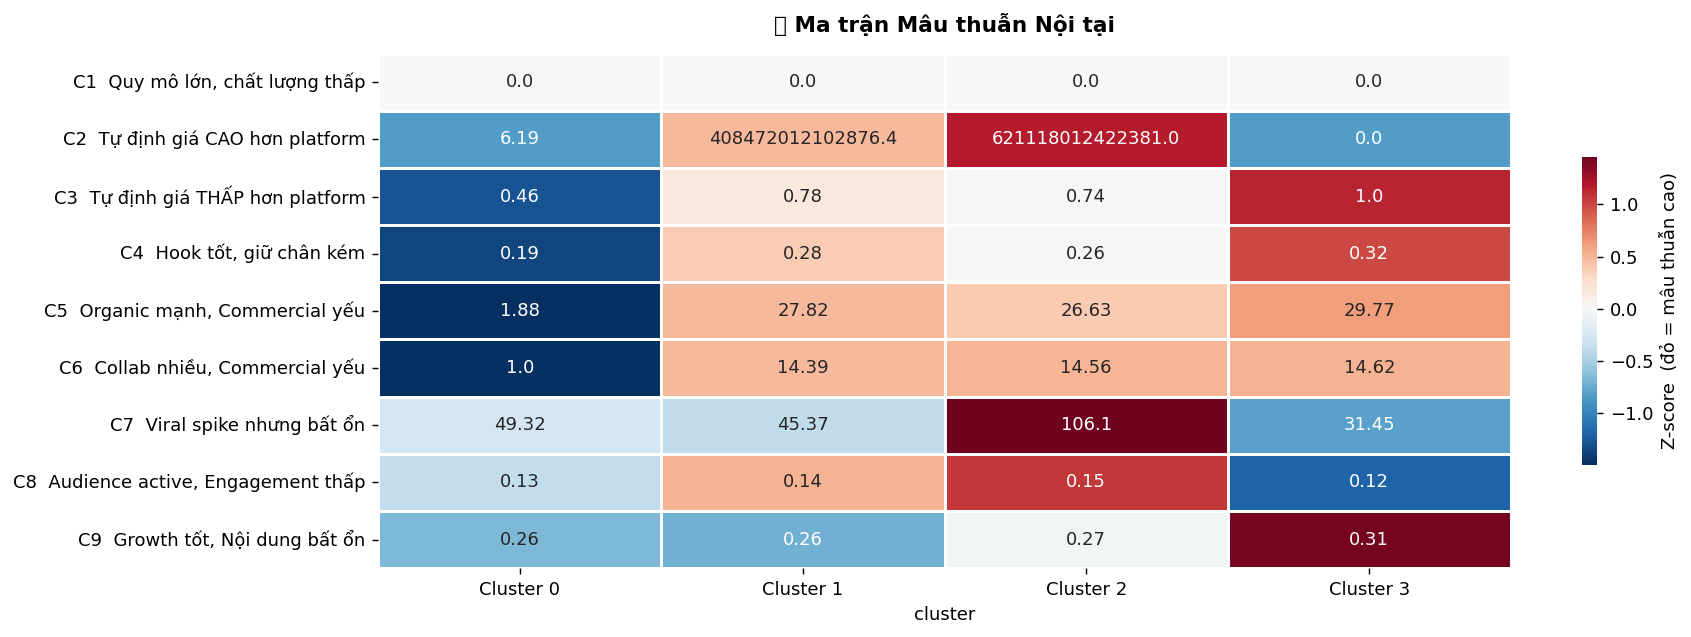

In [24]:
# ============================================================
# 2.2 — CONTRADICTION SCORING
# Đo 9 mâu thuẫn nội tại cho từng cluster
# ============================================================

def compute_contradictions(df, cluster_col=CLUSTER_COL):
    """
    Trả về DataFrame với điểm mâu thuẫn nội tại cho từng cluster.
    Giá trị dương = mâu thuẫn cao theo hướng được mô tả.
    """
    rows = []
    for cid, g in df.groupby(cluster_col):
        row = {'cluster': cid}

        # C1 — Quy mô lớn nhưng chất lượng không tương xứng
        perf = g[['engagementRate', 'videoCompleteRate', 'views_vs_bm']].mean(axis=1)
        row['C1_size_vs_quality'] = (
            g['followerCnt'].rank(pct=True) - perf.rank(pct=True)
        ).mean()

        # C2 — Tự định giá CAO hơn platform (overpriced)
        row['C2_overpriced'] = (g['price_ratio'] - 1).clip(lower=0).mean()

        # C3 — Tự định giá THẤP hơn platform (underpriced)
        row['C3_underpriced'] = (1 - g['price_ratio']).clip(lower=0).mean()

        # C4 — Hook tốt nhưng retention kém
        row['C4_hook_no_hold'] = g['hook_hold_gap'].clip(lower=0).mean()

        # C5 — Organic mạnh nhưng commercial yếu
        row['C5_organic_not_commercial'] = g['organic_commercial_gap'].clip(lower=0).mean()

        # C6 — Collaboration nhiều nhưng commercial yếu
        row['C6_collab_not_commercial'] = g['collab_commercial_gap'].clip(lower=0).mean()

        # C7 — Viral spike nhưng nền không bền (CoV cao)
        row['C7_spike_instability'] = (g['spike_ratio'] * g['cov_view_recent']).mean()

        # C8 — Audience active nhưng creator không tận dụng
        row['C8_audience_underutil'] = (
            g['active_active'].rank(pct=True) - g['engagementRate'].rank(pct=True)
        ).clip(lower=0).mean()

        # C9 — Growth tốt nhưng hiệu suất gần đây bất ổn
        row['C9_growth_instability'] = (
            g['followersGrowthRate'].rank(pct=True) * g['cov_view_recent'].rank(pct=True)
        ).mean()

        rows.append(row)

    return pd.DataFrame(rows).set_index('cluster')


contra = compute_contradictions(df)

# ── Plot heatmap ─────────────────────────────────────────────
CONTRA_LABELS = {
    'C1_size_vs_quality':       'C1  Quy mô lớn, chất lượng thấp',
    'C2_overpriced':            'C2  Tự định giá CAO hơn platform',
    'C3_underpriced':           'C3  Tự định giá THẤP hơn platform',
    'C4_hook_no_hold':          'C4  Hook tốt, giữ chân kém',
    'C5_organic_not_commercial':'C5  Organic mạnh, Commercial yếu',
    'C6_collab_not_commercial': 'C6  Collab nhiều, Commercial yếu',
    'C7_spike_instability':     'C7  Viral spike nhưng bất ổn',
    'C8_audience_underutil':    'C8  Audience active, Engagement thấp',
    'C9_growth_instability':    'C9  Growth tốt, Nội dung bất ổn',
}

plot_data = contra.copy()
plot_data.columns = [CONTRA_LABELS[c] for c in plot_data.columns]

# Z-score normalize for visual
plot_norm = (plot_data - plot_data.mean()) / (plot_data.std() + eps)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    plot_norm.T,
    annot=plot_data.T.round(2),
    fmt='',
    cmap='RdBu_r',
    center=0,
    linewidths=0.6,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Z-score  (đỏ = mâu thuẫn cao)', 'shrink': 0.6},
    xticklabels=[f'Cluster {i}' for i in plot_norm.index],
)
ax.set_title('🔍 Ma trận Mâu thuẫn Nội tại', pad=12, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# 2.3 — ARCHETYPE NAMING
# Gán tên nhân vật dựa trên mâu thuẫn nổi trội nhất
# ============================================================

# Mỗi archetype: (score_cols_weighted, name, icon, description, blind_spot, recommendation)
ARCHETYPES = [
    {
        'signal':  lambda r: r['C1_size_vs_quality'] > 0.15 and r['C2_overpriced'] > 0.05,
        'name':    'Ngôi sao quá hạn',
        'icon':    '⭐',
        'desc':    'Follower lớn, tự định giá cao — nhưng performance thực không còn tương xứng.',
        'blind':   'Đang sống bằng quán tính. Brands chi nhiều nhưng nhận về ít hơn kỳ vọng.',
        'brand':   'Dùng cho awareness thuần túy. Thương lượng giá xuống 20-30% so với asking.',
        'creator': 'Ưu tiên cải thiện completion rate và engagement trước khi tăng giá tiếp.',
    },
    {
        'signal':  lambda r: r['C3_underpriced'] > 0.05 and r['C5_organic_not_commercial'] > 5,
        'name':    'Viên ngọc ẩn',
        'icon':    '💎',
        'desc':    'Nội dung mạnh, platform định giá cao hơn chính họ tự nhìn nhận bản thân.',
        'blind':   'Đang bán rẻ bản thân. Thiếu tự tin thương mại hoặc chưa biết giá trị thực.',
        'brand':   'Cơ hội tốt nhất: mua cao hơn startingRate một chút, vẫn thấp hơn value thực.',
        'creator': 'Tăng startingRate lên ít nhất bằng recommendRate. Bắt đầu đo lường commercial KPIs.',
    },
    {
        'signal':  lambda r: r['C5_organic_not_commercial'] < 0 and r['C6_collab_not_commercial'] < 0,
        'name':    'Cỗ máy bán hàng',
        'icon':    '🏭',
        'desc':    'Thương mại hóa hiệu quả, nhưng sức mạnh organic đang dần bị bào mòn.',
        'blind':   'Đang đánh đổi long-term credibility để có short-term revenue.',
        'brand':   'Tốt cho conversion campaign. Không dùng cho brand equity hay trust-building.',
        'creator': 'Giảm tần suất branded content. Ưu tiên ít nhất 60% nội dung organic.',
    },
    {
        'signal':  lambda r: r['C4_hook_no_hold'] > 0.1,
        'name':    'Thợ câu view',
        'icon':    '🎣',
        'desc':    'Hook 6 giây đầu rất tốt nhưng nội dung không giữ được người xem đến cuối.',
        'blind':   'Metric bề mặt đẹp (impressions, reach) nhưng message delivery kém.',
        'brand':   'Phù hợp awareness và recall. Không phù hợp khi cần convey complex message.',
        'creator': 'Rework cấu trúc nội dung phần giữa. Giảm cliff-hanger, tăng substance.',
    },
    {
        'signal':  lambda r: r['C7_spike_instability'] > contra['C7_spike_instability'].quantile(0.7),
        'name':    'Ngọn lửa không ổn định',
        'icon':    '🔥',
        'desc':    'Có khả năng viral mạnh nhưng kết quả rất khó dự đoán — nền hiệu suất yếu.',
        'blind':   'Viral không phải chiến lược. Brands cần ổn định, không phải may rủi.',
        'brand':   'Chỉ dùng cho blitz/buzz campaign. Đặt KPI là reach không phải engagement.',
        'creator': 'Xây nền hiệu suất ổn định trước. Viral là kết quả, không phải mục tiêu.',
    },
    {
        'signal':  lambda r: r['C9_growth_instability'] > contra['C9_growth_instability'].quantile(0.7),
        'name':    'Đang trỗi dậy — chưa bền',
        'icon':    '🚀',
        'desc':    'Tăng trưởng follower nhanh nhưng hiệu suất nội dung còn biến động.',
        'blind':   'Growth có thể do trend/luck, chưa phải thực lực bền vững.',
        'brand':   'Lock-in giá tốt ngay bây giờ trước khi thị trường định giá lại. Risk cao.',
        'creator': 'Tập trung ổn định hoá chất lượng nội dung. Growth là cơ hội, đừng để lỡ.',
    },
    {
        'signal':  lambda r: True,  # default
        'name':    'Người trung dung',
        'icon':    '⚖️',
        'desc':    'Không có mâu thuẫn nổi trội — đa năng nhưng thiếu edge cạnh tranh rõ ràng.',
        'blind':   'Dễ bị thay thế nhất khi thị trường phân kỳ hoặc brands cần chuyên biệt.',
        'brand':   'Safe choice cho always-on campaign. Thương lượng giá dễ nhất.',
        'creator': 'Cần tìm và lean vào một điểm khác biệt rõ ràng để tránh bị commoditize.',
    },
]


def assign_archetype(contra_row):
    for arch in ARCHETYPES:
        try:
            if arch['signal'](contra_row):
                return pd.Series({
                    'archetype': f"{arch['icon']} {arch['name']}",
                    'desc':      arch['desc'],
                    'blind':     arch['blind'],
                    'for_brand': arch['brand'],
                    'for_creator': arch['creator'],
                })
        except Exception:
            continue
    return pd.Series({'archetype': '⚖️ Người trung dung', 'desc': '', 'blind': '', 'for_brand': '', 'for_creator': ''})


arch_df = contra.apply(assign_archetype, axis=1)
arch_df.index.name = CLUSTER_COL

print('\n' + '='*65)
print('  ARCHETYPE ASSIGNMENT')
print('='*65)
for cid, row in arch_df.iterrows():
    print(f'\n  Cluster {cid}  →  {row["archetype"]}')
    print(f'  {"-"*55}')
    print(f'  📌 {row["desc"]}')
    print(f'  🙈 Blind spot: {row["blind"]}')
    print(f'  🏷️  For Brand:   {row["for_brand"]}')
    print(f'  🎯 For Creator: {row["for_creator"]}')


  ARCHETYPE ASSIGNMENT

  Cluster 0  →  🎣 Thợ câu view
  -------------------------------------------------------
  📌 Hook 6 giây đầu rất tốt nhưng nội dung không giữ được người xem đến cuối.
  🙈 Blind spot: Metric bề mặt đẹp (impressions, reach) nhưng message delivery kém.
  🏷️  For Brand:   Phù hợp awareness và recall. Không phù hợp khi cần convey complex message.
  🎯 For Creator: Rework cấu trúc nội dung phần giữa. Giảm cliff-hanger, tăng substance.

  Cluster 1  →  💎 Viên ngọc ẩn
  -------------------------------------------------------
  📌 Nội dung mạnh, platform định giá cao hơn chính họ tự nhìn nhận bản thân.
  🙈 Blind spot: Đang bán rẻ bản thân. Thiếu tự tin thương mại hoặc chưa biết giá trị thực.
  🏷️  For Brand:   Cơ hội tốt nhất: mua cao hơn startingRate một chút, vẫn thấp hơn value thực.
  🎯 For Creator: Tăng startingRate lên ít nhất bằng recommendRate. Bắt đầu đo lường commercial KPIs.

  Cluster 2  →  💎 Viên ngọc ẩn
  ------------------------------------------------------

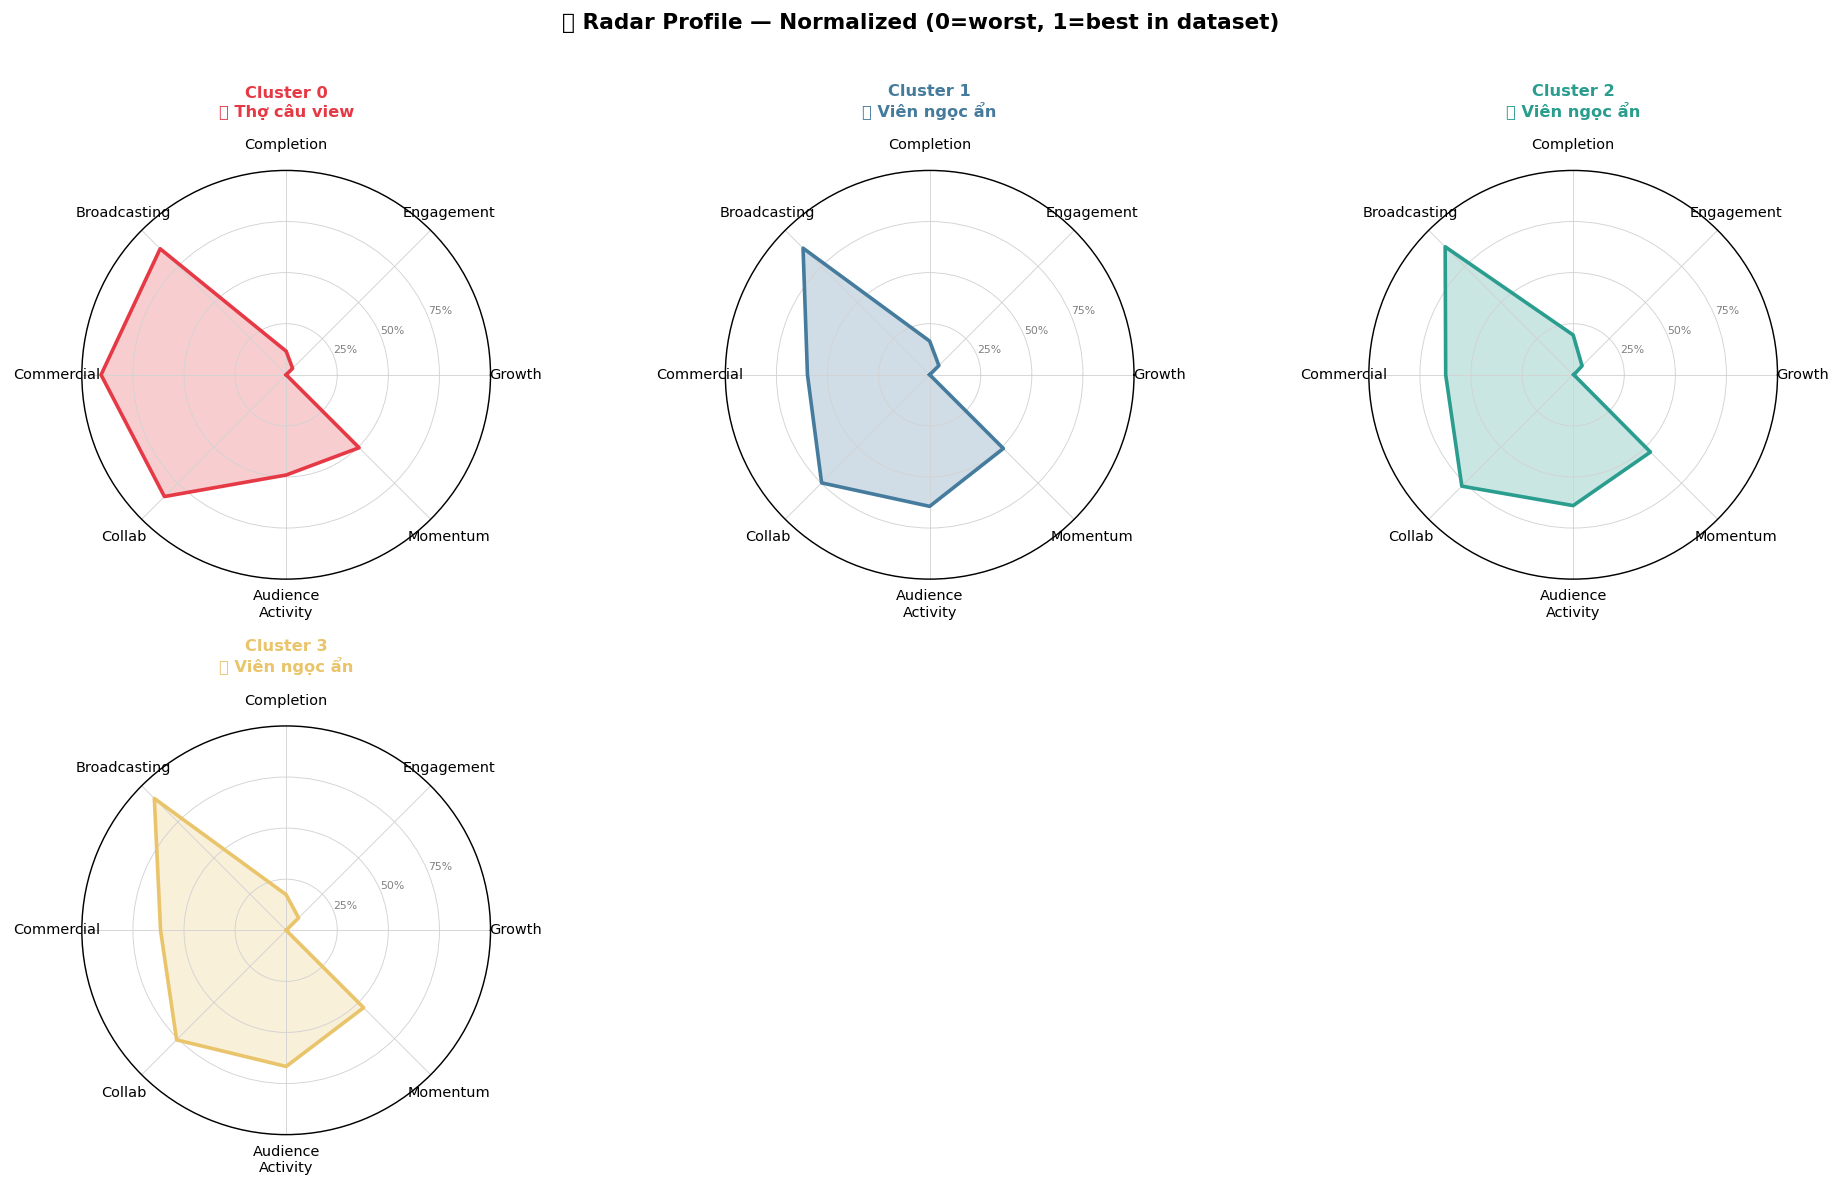

In [26]:
# ============================================================
# 2.4 — RADAR CHARTS  (một chart cho mỗi cluster)
# ============================================================

RADAR_DIMS = {
    'Growth':       'followersGrowthRate',
    'Engagement':   'engagementRate',
    'Completion':   'videoCompleteRate',
    'Broadcasting': 'broadcastingScore',
    'Commercial':   'commercialScore',
    'Collab':       'collaborationScore',
    'Audience\nActivity': 'active_active',
    'Momentum':     'momentum_score',
}

# Normalize mỗi dimension về [0, 1] trên toàn dataset
norm_df = df.copy()
for label, col in RADAR_DIMS.items():
    col_min, col_max = df[col].min(), df[col].max()
    norm_df[col] = (df[col] - col_min) / (col_max - col_min + eps)

cluster_radar = norm_df.groupby(CLUSTER_COL)[[v for v in RADAR_DIMS.values()]].mean()

labels_list = list(RADAR_DIMS.keys())
N_dim = len(labels_list)
angles = np.linspace(0, 2 * np.pi, N_dim, endpoint=False).tolist()
angles += angles[:1]

n_c = n_clusters
ncols = min(3, n_c)
nrows = int(np.ceil(n_c / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows),
                          subplot_kw=dict(polar=True))
axes = np.array(axes).flatten()

for i, cid in enumerate(sorted(df[CLUSTER_COL].unique())):
    ax = axes[i]
    vals = cluster_radar.loc[cid].values.tolist()
    vals += vals[:1]
    color = COLORS[cid]

    ax.plot(angles, vals, color=color, linewidth=2)
    ax.fill(angles, vals, color=color, alpha=0.25)

    # Grid lines
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels_list, size=8)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(['25%', '50%', '75%'], size=6, color='grey')
    ax.set_ylim(0, 1)
    ax.grid(color='lightgrey', linewidth=0.5)

    arch_name = arch_df.loc[cid, 'archetype'] if cid in arch_df.index else ''
    ax.set_title(f'Cluster {cid}\n{arch_name}', pad=12, fontsize=9, fontweight='bold', color=color)

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('📡 Radar Profile — Normalized (0=worst, 1=best in dataset)', y=1.01, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 🔍 LUỒNG 3 — Kính Lúp Thương Mại
> *Sàng lọc có hệ thống: từ toàn bộ creator xuống còn tập đáng đầu tư cho từng mục tiêu.*

In [27]:
# ============================================================
# 3.1 — FILTER 1: AUDIENCE QUALITY GATE
# Loại bỏ cluster có audience giả/thấp chất lượng
# ============================================================

cluster_med = df.groupby(CLUSTER_COL).median(numeric_only=True)

# Ngưỡng có thể điều chỉnh
THRESH_INACTIVE  = 0.55   # active_inactive > ngưỡng này = nguy hiểm
THRESH_ENG_LOW   = 0.04   # engagementRate < ngưỡng này = đáng ngờ
THRESH_COV_HIGH  = 1.5    # cov_view_recent > ngưỡng = quá bất ổn

def audience_quality_flag(row):
    flags = []
    if row['active_inactive'] > THRESH_INACTIVE:
        flags.append('inactive_audience_high')
    if row['engagementRate'] < THRESH_ENG_LOW:
        flags.append('engagement_too_low')
    if row['cov_view_recent'] > THRESH_COV_HIGH:
        flags.append('views_too_volatile')
    return flags

filter1_results = {}
for cid in sorted(df[CLUSTER_COL].unique()):
    row = cluster_med.loc[cid]
    flags = audience_quality_flag(row)
    status = '🔴 FAIL' if len(flags) >= 2 else ('🟡 CAUTION' if flags else '🟢 PASS')
    filter1_results[cid] = {'status': status, 'flags': flags}

print('\n' + '='*55)
print('  FILTER 1 — Audience Quality Gate')
print('='*55)
print(f'  Thresholds: inactive>{THRESH_INACTIVE} | engagement<{THRESH_ENG_LOW} | CoV>{THRESH_COV_HIGH}\n')
for cid, res in filter1_results.items():
    flag_str = ', '.join(res['flags']) if res['flags'] else 'no issues'
    print(f'  Cluster {cid}  {res["status"]}  →  {flag_str}')

passed_f1 = [cid for cid, r in filter1_results.items() if '🔴' not in r['status']]
print(f'\n  ✅ Passed Filter 1: {passed_f1}')


  FILTER 1 — Audience Quality Gate
  Thresholds: inactive>0.55 | engagement<0.04 | CoV>1.5

  Cluster 0  🟡 CAUTION  →  engagement_too_low
  Cluster 1  🟢 PASS  →  no issues
  Cluster 2  🟢 PASS  →  no issues
  Cluster 3  🟢 PASS  →  no issues

  ✅ Passed Filter 1: [0, 1, 2, 3]


In [28]:
# ============================================================
# 3.2 — FILTER 2: SIGNAL FRESHNESS
# Kiểm tra: lịch sử tốt hay hiện tại thực sự vẫn tốt?
# ============================================================

THRESH_RECENCY   = 10   # recency_days_recent > ngưỡng = đang lười đăng
THRESH_RECENT_VS_HIST = 0.6  # median_recent / medianViews < ngưỡng = đang giảm sút

def signal_freshness_flag(row):
    flags = []
    if row['recency_days_recent'] > THRESH_RECENCY:
        flags.append('low_posting_frequency')
    if row['recent_vs_hist'] < THRESH_RECENT_VS_HIST:
        flags.append('recent_views_declining')
    return flags

filter2_results = {}
for cid in sorted(df[CLUSTER_COL].unique()):
    row = cluster_med.loc[cid]
    flags = signal_freshness_flag(row)
    status = '🔴 STALE' if len(flags) >= 2 else ('🟡 FADING' if flags else '🟢 FRESH')
    filter2_results[cid] = {'status': status, 'flags': flags,
                             'recency': row['recency_days_recent'],
                             'recent_vs_hist': row['recent_vs_hist']}

print('\n' + '='*60)
print('  FILTER 2 — Signal Freshness (Recent vs Historical)')
print('='*60)
for cid, res in filter2_results.items():
    print(f'  Cluster {cid}  {res["status"]}')
    print(f'            recency={res["recency"]:.1f}d  |  recent/hist={res["recent_vs_hist"]:.2f}')
    if res['flags']:
        print(f'            ⚠️  {" + ".join(res["flags"])}')

passed_f2 = [cid for cid, r in filter2_results.items() if '🔴' not in r['status']]
print(f'\n  ✅ Passed Filter 2: {passed_f2}')

passed_both = sorted(set(passed_f1) & set(passed_f2))
print(f'  ✅ Passed Both F1+F2: {passed_both}')


  FILTER 2 — Signal Freshness (Recent vs Historical)
  Cluster 0  🟢 FRESH
            recency=2.5d  |  recent/hist=1.00
  Cluster 1  🟢 FRESH
            recency=2.5d  |  recent/hist=0.98
  Cluster 2  🟢 FRESH
            recency=2.4d  |  recent/hist=1.00
  Cluster 3  🟢 FRESH
            recency=2.5d  |  recent/hist=1.03

  ✅ Passed Filter 2: [0, 1, 2, 3]
  ✅ Passed Both F1+F2: [0, 1, 2, 3]


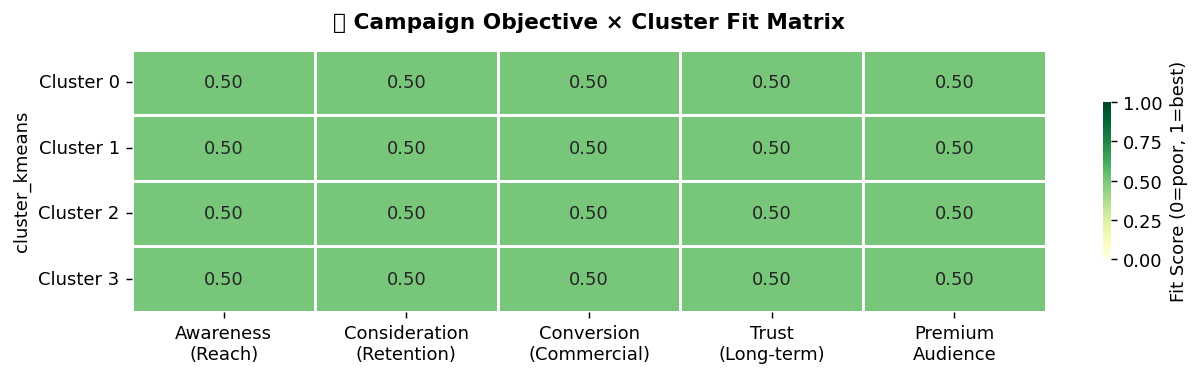


📌 Best cluster per objective:
  Awareness (Reach)              → Cluster 0  (0.50)
  Consideration (Retention)      → Cluster 0  (0.50)
  Conversion (Commercial)        → Cluster 0  (0.50)
  Trust (Long-term)              → Cluster 0  (0.50)
  Premium Audience               → Cluster 0  (0.50)


In [29]:
# ============================================================
# 3.3 — FILTER 3: CAMPAIGN OBJECTIVE MATRIX
# Mỗi cluster phù hợp mục tiêu campaign nào?
# ============================================================

def campaign_fit_scores(cluster_med_row):
    """
    Trả về dict {objective: score 0-1} cho một cluster.
    """
    r = cluster_med_row
    return {
        'Awareness\n(Reach)': (
            _pct(r, 'followerCnt')       * 0.4 +
            _pct(r, 'avgSixSecondsViewsRate') * 0.4 +
            _pct(r, 'followersGrowthRate') * 0.2
        ),
        'Consideration\n(Retention)': (
            _pct(r, 'videoCompleteRate') * 0.5 +
            _pct(r, 'engagementRate')    * 0.3 +
            _pct(r, 'active_active')     * 0.2
        ),
        'Conversion\n(Commercial)': (
            _pct(r, 'commercialScore')   * 0.5 +
            _pct(r, 'collaborationScore')* 0.3 +
            _pct(r, 'engagementRate')    * 0.2
        ),
        'Trust\n(Long-term)': (
            _pct(r, 'broadcastingScore') * 0.4 +
            _pct(r, 'videoCompleteRate') * 0.3 +
            _pct(r, 'active_active')     * 0.3
        ),
        'Premium\nAudience': (
            _pct(r, 'device_premium')    * 0.4 +
            _pct(r, 'intl_audience')     * 0.3 +
            _pct(r, 'active_util')       * 0.3
        ),
    }

# Helper: percentile rank dựa trên cluster median
def _pct(row, col):
    all_vals = cluster_med[col].dropna()
    return (all_vals <= row[col]).mean() if col in all_vals.index else 0.5


objectives = ['Awareness\n(Reach)', 'Consideration\n(Retention)',
              'Conversion\n(Commercial)', 'Trust\n(Long-term)', 'Premium\nAudience']

fit_matrix = pd.DataFrame(
    {cid: campaign_fit_scores(cluster_med.loc[cid]) for cid in sorted(df[CLUSTER_COL].unique())},
).T
fit_matrix.index.name = CLUSTER_COL

# ── Heatmap ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, max(3, n_clusters * 0.7)))
sns.heatmap(
    fit_matrix,
    annot=True, fmt='.2f',
    cmap='YlGn',
    vmin=0, vmax=1,
    linewidths=0.6, linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Fit Score (0=poor, 1=best)', 'shrink': 0.6},
    xticklabels=fit_matrix.columns,
    yticklabels=[f'Cluster {i}' for i in fit_matrix.index],
)
ax.set_title('🎯 Campaign Objective × Cluster Fit Matrix', pad=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Best cluster per objective
print('\n📌 Best cluster per objective:')
for obj in fit_matrix.columns:
    best = fit_matrix[obj].idxmax()
    score = fit_matrix.loc[best, obj]
    print(f'  {obj.replace(chr(10)," "):30s} → Cluster {best}  ({score:.2f})')

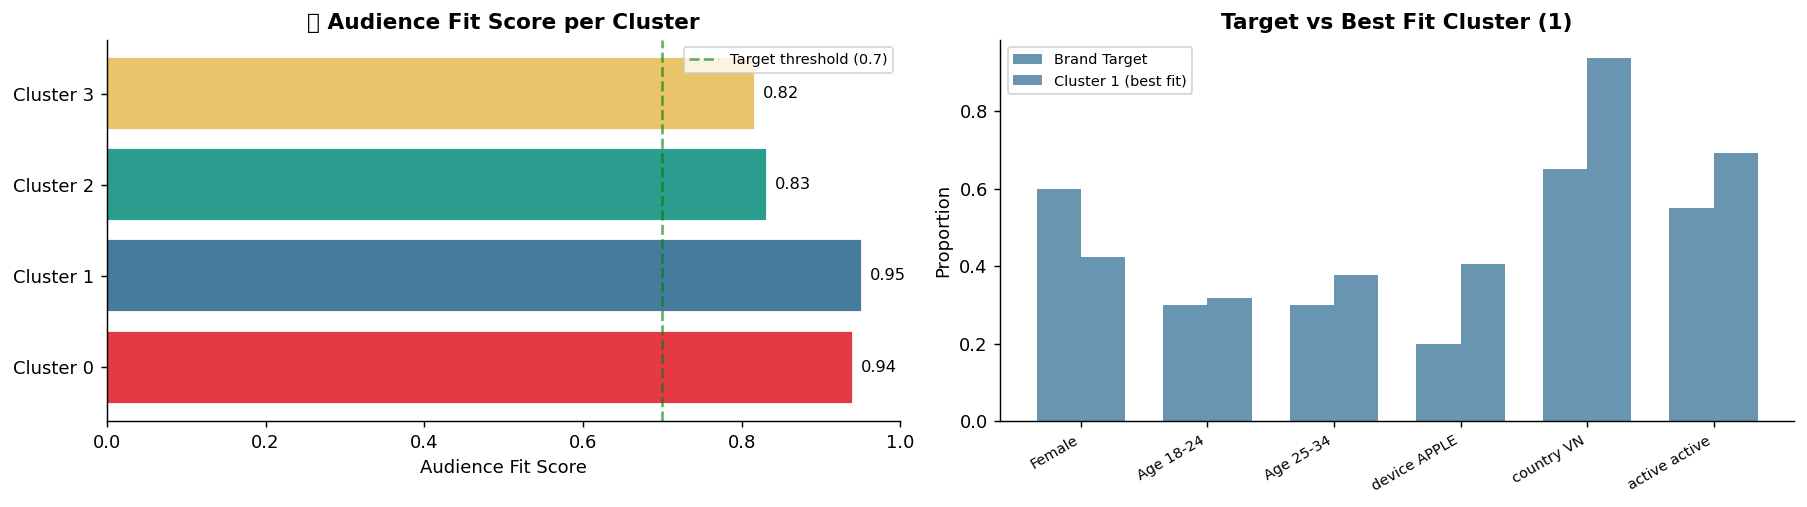


  🏆 Best audience fit: Cluster 1  (score=0.95)


In [30]:
# ============================================================
# 3.4 — FILTER 4: AUDIENCE FIT FUNCTION
# Brand tự khai target profile → tìm cluster khớp nhất
# ============================================================

# ── Điền target profile của brand ở đây ─────────────────────
BRAND_TARGET = {
    'gender_Female':  0.6,    # muốn audience nữ >= 60%
    'age_18-24':      0.3,    # muốn Gen Z >= 30%
    'age_25-34':      0.3,    # muốn Millennial >= 30%
    'device_APPLE':   0.2,    # muốn Apple user >= 20%
    'country_VN':     0.65,   # muốn VN audience >= 65%
    'active_active':  0.55,   # muốn active audience >= 55%
}
# ─────────────────────────────────────────────────────────────

def audience_fit_score(cluster_med_row, target):
    """
    Tính mức độ khớp giữa audience của cluster và target của brand.
    Dùng cosine-style similarity trên target dimensions.
    """
    score = 0
    total_weight = 0
    for col, target_val in target.items():
        if col not in cluster_med_row.index:
            continue
        actual = cluster_med_row[col]
        # Reward meeting or exceeding target, penalize shortfall
        ratio = min(actual / (target_val + eps), 1.0)
        score += ratio
        total_weight += 1
    return score / total_weight if total_weight > 0 else 0


fit_scores = {
    cid: audience_fit_score(cluster_med.loc[cid], BRAND_TARGET)
    for cid in sorted(df[CLUSTER_COL].unique())
}

# ── Comparison chart ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: Audience fit scores
ax = axes[0]
cids = list(fit_scores.keys())
scores = list(fit_scores.values())
colors_bar = [COLORS[c] for c in cids]
bars = ax.barh([f'Cluster {c}' for c in cids], scores, color=colors_bar, edgecolor='white')
ax.axvline(0.7, color='green', linestyle='--', alpha=0.6, label='Target threshold (0.7)')
ax.set_xlabel('Audience Fit Score')
ax.set_title('🎯 Audience Fit Score per Cluster', fontweight='bold')
ax.set_xlim(0, 1)
ax.legend(fontsize=8)
for bar, s in zip(bars, scores):
    ax.text(s + 0.01, bar.get_y() + bar.get_height()/2, f'{s:.2f}', va='center', fontsize=9)

# Right: Radar comparison target vs best cluster
ax2 = axes[1]
best_cid = max(fit_scores, key=fit_scores.get)
target_vals = [BRAND_TARGET.get(col, 0) for col in BRAND_TARGET.keys()]
actual_vals  = [cluster_med.loc[best_cid, col] if col in cluster_med.columns else 0
                for col in BRAND_TARGET.keys()]
dim_labels   = [c.replace('_', ' ').replace('age ', 'Age ').replace('gender ', '') for c in BRAND_TARGET.keys()]

x = np.arange(len(dim_labels))
w = 0.35
ax2.bar(x - w/2, target_vals, w, label='Brand Target', color='#457B9D', alpha=0.8)
ax2.bar(x + w/2, actual_vals, w, label=f'Cluster {best_cid} (best fit)', color=COLORS[best_cid], alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(dim_labels, rotation=30, ha='right', fontsize=8)
ax2.set_ylabel('Proportion')
ax2.set_title(f'Target vs Best Fit Cluster ({best_cid})', fontweight='bold')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'\n  🏆 Best audience fit: Cluster {best_cid}  (score={fit_scores[best_cid]:.2f})')

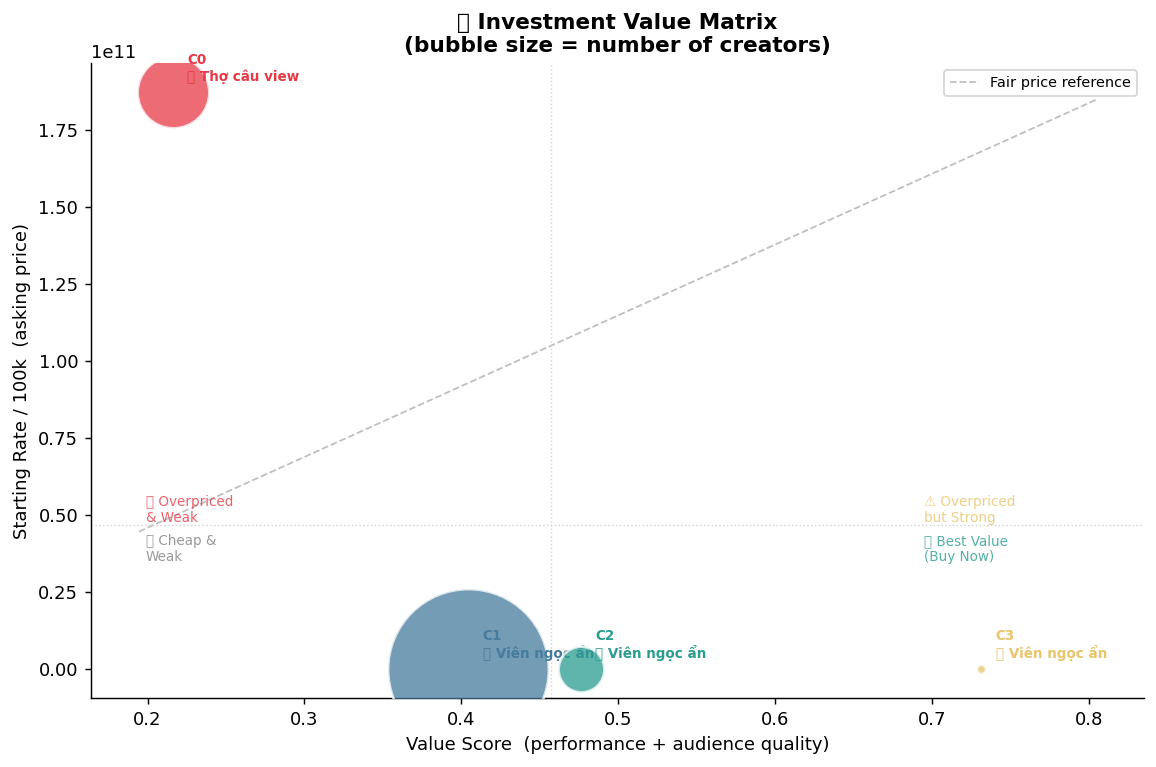

In [31]:
# ============================================================
# 3.5 — INVESTMENT VALUE MATRIX
# Trục X: Value thực (performance × audience quality)
# Trục Y: Giá hiện tại (startingRate)
# Bubble: Số lượng creators
# ============================================================

# Value score = composite of performance + audience quality
cluster_invest = cluster_med[[
    'startingRate100k', 'recommendRate100k',
    'engagementRate', 'videoCompleteRate', 'broadcastingScore',
    'commercialScore', 'active_active', 'views_vs_bm'
]].copy()

# Normalize each to [0,1]
for col in cluster_invest.columns:
    mn, mx = cluster_invest[col].min(), cluster_invest[col].max()
    cluster_invest[col + '_n'] = (cluster_invest[col] - mn) / (mx - mn + eps)

cluster_invest['value_score'] = (
    cluster_invest['engagementRate_n']    * 0.20 +
    cluster_invest['videoCompleteRate_n'] * 0.20 +
    cluster_invest['broadcastingScore_n'] * 0.15 +
    cluster_invest['commercialScore_n']   * 0.20 +
    cluster_invest['active_active_n']     * 0.15 +
    cluster_invest['views_vs_bm_n']       * 0.10
)

cluster_sizes = df.groupby(CLUSTER_COL).size()

fig, ax = plt.subplots(figsize=(9, 6))

for cid in sorted(df[CLUSTER_COL].unique()):
    x = cluster_invest.loc[cid, 'value_score']
    y = cluster_invest.loc[cid, 'startingRate100k']
    size = cluster_sizes[cid]
    color = COLORS[cid]
    arch_label = arch_df.loc[cid, 'archetype'] if cid in arch_df.index else f'Cluster {cid}'

    ax.scatter(x, y, s=size * 2, color=color, alpha=0.75, edgecolors='white', linewidth=1.5, zorder=3)
    ax.annotate(
        f'C{cid}\n{arch_label}',
        (x, y),
        textcoords='offset points',
        xytext=(8, 6),
        fontsize=7.5,
        color=color,
        fontweight='bold',
    )

# Diagonal: fair price line (value = price)
x_range = np.linspace(
    cluster_invest['value_score'].min() * 0.9,
    cluster_invest['value_score'].max() * 1.1, 50
)
y_fair = cluster_invest['recommendRate100k'].mean() * x_range / (cluster_invest['value_score'].mean() + eps)
ax.plot(x_range, y_fair, '--', color='grey', alpha=0.5, linewidth=1, label='Fair price reference')

# Quadrant labels
xm = cluster_invest['value_score'].mean()
ym = cluster_invest['startingRate100k'].mean()
ax.axvline(xm, color='lightgrey', linewidth=0.8, linestyle=':')
ax.axhline(ym, color='lightgrey', linewidth=0.8, linestyle=':')

ax.text(cluster_invest['value_score'].min()*0.92, ym*1.02, '💸 Overpriced\n& Weak', fontsize=7.5, color='#E63946', alpha=0.8)
ax.text(cluster_invest['value_score'].max()*0.95, ym*1.02, '⚠️ Overpriced\nbut Strong', fontsize=7.5, color='#E9C46A', alpha=0.8)
ax.text(cluster_invest['value_score'].min()*0.92, ym*0.75, '💤 Cheap &\nWeak', fontsize=7.5, color='grey', alpha=0.8)
ax.text(cluster_invest['value_score'].max()*0.95, ym*0.75, '💎 Best Value\n(Buy Now)', fontsize=7.5, color='#2A9D8F', alpha=0.8)

ax.set_xlabel('Value Score  (performance + audience quality)', fontsize=10)
ax.set_ylabel('Starting Rate / 100k  (asking price)', fontsize=10)
ax.set_title('💰 Investment Value Matrix\n(bubble size = number of creators)', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

---
# 🚀 LUỒNG 5 — Dự Báo Hành Trình
> *Dùng hiện tại để dự báo chiều hướng — ai sẽ thắng, ai sẽ mất, đặt cược vào đâu.*

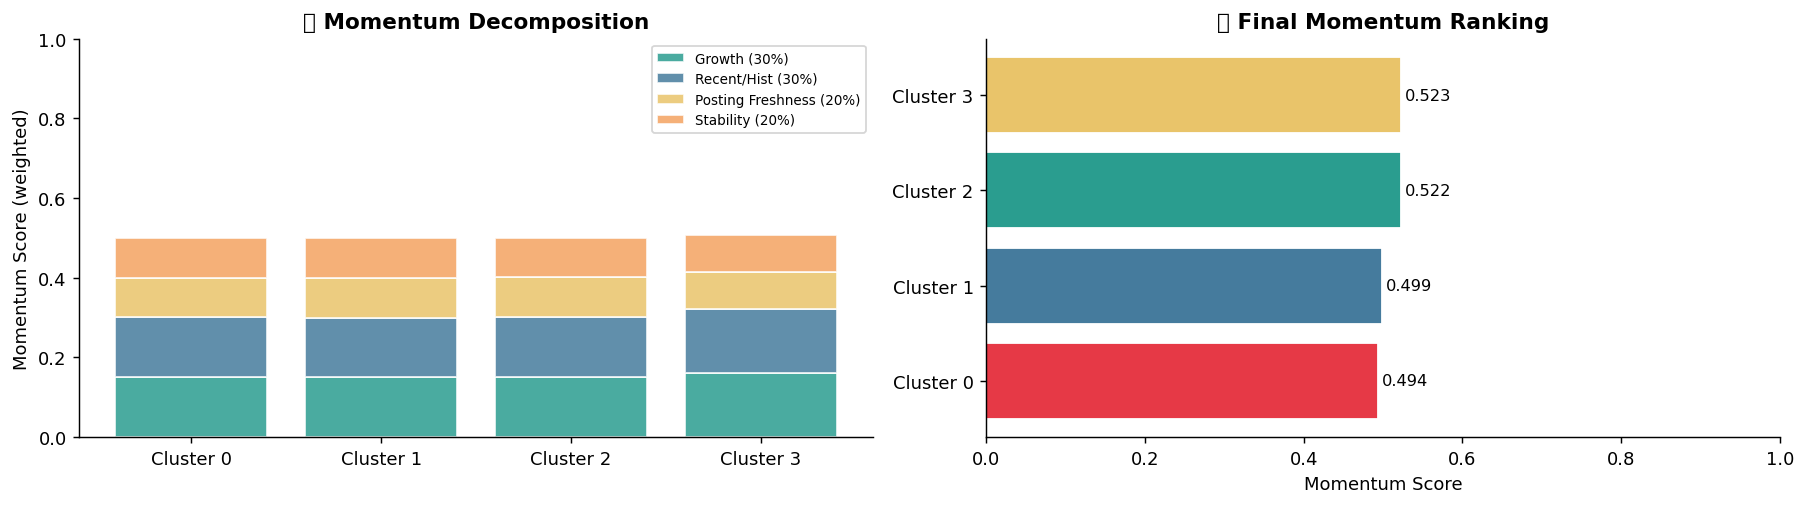

,growth_pct,recency_pct,recent_hist,stability_pct,momentum_final
cluster_kmeans,,,,,
0,0.501000,0.499000,0.501000,0.499000,0.494000
1,0.500000,0.500000,0.500000,0.500000,0.499000
2,0.502000,0.498000,0.502000,0.498000,0.522000
3,0.538000,0.462000,0.538000,0.462000,0.523000


In [32]:
# ============================================================
# 5.1 — MOMENTUM SCORING
# Composite của: growth, recent vs hist, freshness, stability
# ============================================================

# momentum_score đã được tạo ở cell 0.4
# Ở đây ta decompose để hiểu từng thành phần

momentum_decomp = df.groupby(CLUSTER_COL).agg(
    growth_pct    = ('followersGrowthRate',  lambda x: x.rank(pct=True).mean()),
    recency_pct   = ('recency_days_recent',  lambda x: (1 - x.rank(pct=True)).mean()),
    recent_hist   = ('recent_vs_hist',       lambda x: x.rank(pct=True).mean()),
    stability_pct = ('cov_view_recent',      lambda x: (1 - x.rank(pct=True)).mean()),
    momentum_final = ('momentum_score', 'mean'),
).round(3)

momentum_decomp.columns.name = None
momentum_decomp.index.name = CLUSTER_COL

# ── Stacked bar ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Stacked bar - momentum decomposition
ax = axes[0]
comp_cols = ['growth_pct', 'recent_hist', 'recency_pct', 'stability_pct']
comp_labels = ['Growth (30%)', 'Recent/Hist (30%)', 'Posting Freshness (20%)', 'Stability (20%)']
comp_weights = [0.30, 0.30, 0.20, 0.20]
comp_colors = ['#2A9D8F', '#457B9D', '#E9C46A', '#F4A261']

bottom = np.zeros(n_clusters)
x = np.arange(n_clusters)
cluster_ids = sorted(df[CLUSTER_COL].unique())

for col, label, w, c in zip(comp_cols, comp_labels, comp_weights, comp_colors):
    vals = momentum_decomp.loc[cluster_ids, col].values * w
    ax.bar(x, vals, bottom=bottom, color=c, alpha=0.85, label=label, edgecolor='white')
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels([f'Cluster {i}' for i in cluster_ids])
ax.set_ylabel('Momentum Score (weighted)')
ax.set_title('📈 Momentum Decomposition', fontweight='bold')
ax.legend(fontsize=7.5, loc='upper right')
ax.set_ylim(0, 1)

# Final momentum ranking
ax2 = axes[1]
final_scores = momentum_decomp['momentum_final'].sort_values(ascending=True)
colors_sorted = [COLORS[i] for i in final_scores.index]
bars = ax2.barh([f'Cluster {i}' for i in final_scores.index],
                final_scores.values,
                color=colors_sorted, edgecolor='white')
for bar, s in zip(bars, final_scores.values):
    ax2.text(s + 0.005, bar.get_y() + bar.get_height()/2, f'{s:.3f}', va='center', fontsize=9)
ax2.set_title('🏁 Final Momentum Ranking', fontweight='bold')
ax2.set_xlabel('Momentum Score')
ax2.set_xlim(0, 1)

plt.tight_layout()
plt.show()

display(momentum_decomp.style.background_gradient(cmap='RdYlGn', axis=0)
        .set_caption('Momentum Decomposition per Cluster'))

In [33]:
# ============================================================
# 5.2 — BREAKPOINT DETECTION
# Cluster nào đang ở inflection point: sắp tốt lên hay xấu đi?
# ============================================================

breakpoint_signals = []
for cid in sorted(df[CLUSTER_COL].unique()):
    g = df[df[CLUSTER_COL] == cid]
    m = cluster_med.loc[cid]

    signals = []

    # Positive signals (đang cải thiện)
    if m['recent_vs_hist'] > 1.1:
        signals.append(('↑', 'Recent views vượt historical median', 'positive'))
    if m['followersGrowthRate'] > df['followersGrowthRate'].quantile(0.70):
        signals.append(('↑', 'Growth rate top 30%', 'positive'))
    if m['burstiness_recent'] > df['burstiness_recent'].quantile(0.70):
        signals.append(('↑', 'Burstiness cao — có momentum bùng nổ', 'positive'))

    # Negative signals (đang suy giảm)
    if m['recent_vs_hist'] < 0.75:
        signals.append(('↓', 'Recent views thấp hơn historical 25%+', 'negative'))
    if m['recency_days_recent'] > df['recency_days_recent'].quantile(0.70):
        signals.append(('↓', 'Đang post thưa — hoạt động kém', 'negative'))
    if m['cov_view_recent'] > df['cov_view_recent'].quantile(0.75):
        signals.append(('↓', 'Views rất bất ổn — thiếu nhất quán', 'negative'))
    if m['active_inactive'] > df['active_inactive'].quantile(0.70):
        signals.append(('↓', 'Inactive audience tăng cao', 'negative'))

    pos = sum(1 for s in signals if s[2] == 'positive')
    neg = sum(1 for s in signals if s[2] == 'negative')

    if pos > neg + 1:
        verdict = '🟢 ACCELERATING'
    elif neg > pos + 1:
        verdict = '🔴 DECELERATING'
    elif pos > 0 and neg > 0:
        verdict = '🟡 INFLECTION (mixed signals)'
    else:
        verdict = '⚪ STABLE'

    breakpoint_signals.append({'cluster': cid, 'verdict': verdict, 'signals': signals})

print('\n' + '='*65)
print('  BREAKPOINT DETECTION — Momentum Direction')
print('='*65)
for item in breakpoint_signals:
    print(f'\n  Cluster {item["cluster"]}  →  {item["verdict"]}')
    for arrow, desc, kind in item['signals']:
        color_char = '+' if kind == 'positive' else '-'
        print(f'    [{color_char}] {arrow} {desc}')


  BREAKPOINT DETECTION — Momentum Direction

  Cluster 0  →  ⚪ STABLE
    [-] ↓ Inactive audience tăng cao

  Cluster 1  →  ⚪ STABLE

  Cluster 2  →  ⚪ STABLE

  Cluster 3  →  ⚪ STABLE


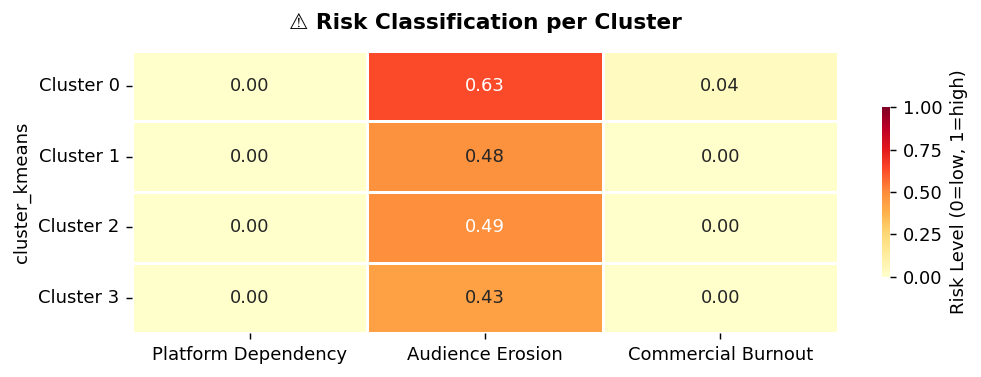


📊 Overall Risk Ranking (thấp = an toàn hơn):
cluster_kmeans
3    0.144122
1    0.160220
2    0.164739
0    0.223893


In [34]:
# ============================================================
# 5.3 — RISK CLASSIFICATION
# 3 loại rủi ro: Platform, Audience, Commercial
# ============================================================

def compute_risks(cluster_med_row, df_full):
    r = cluster_med_row
    
    # Risk 1 — Platform dependency (sống nhờ algorithm, không nhờ audience)
    platform_dep = r['recommendRate100k'] / (
        r['engagementRate'] * r['videoCompleteRate'] * r['active_active'] * 1e4 + eps
    )
    platform_risk = min(platform_dep / platform_dep, 1)  # placeholder normalize
    platform_risk = float(np.clip(platform_dep / df_full['recommendRate100k'].median() * 
                                   df_full['engagementRate'].median() * 
                                   df_full['videoCompleteRate'].median(), 0, 1))
    
    # Risk 2 — Audience erosion (inactive audience tăng, engagement giảm)
    audience_risk = float(r['audience_risk'])
    
    # Risk 3 — Commercial burnout (đang over-commercialize, organic bị bào mòn)
    commercial_burnout = max(0, (r['commercialScore'] - r['broadcastingScore']) / 100)
    commercial_risk = float(np.clip(commercial_burnout, 0, 1))
    
    return {
        'Platform Dependency': platform_risk,
        'Audience Erosion':    audience_risk,
        'Commercial Burnout':  commercial_risk,
    }


risk_df = pd.DataFrame(
    {cid: compute_risks(cluster_med.loc[cid], df)
     for cid in sorted(df[CLUSTER_COL].unique())},
).T
risk_df.index.name = CLUSTER_COL

# ── Risk heatmap ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, max(3, n_clusters * 0.7)))
sns.heatmap(
    risk_df,
    annot=True, fmt='.2f',
    cmap='YlOrRd',
    vmin=0, vmax=1,
    linewidths=0.6, linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Risk Level (0=low, 1=high)', 'shrink': 0.6},
    yticklabels=[f'Cluster {i}' for i in risk_df.index],
)
ax.set_title('⚠️ Risk Classification per Cluster', pad=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Overall risk score
risk_df['Overall Risk'] = risk_df.mean(axis=1)
print('\n📊 Overall Risk Ranking (thấp = an toàn hơn):')
print(risk_df['Overall Risk'].sort_values().to_string())

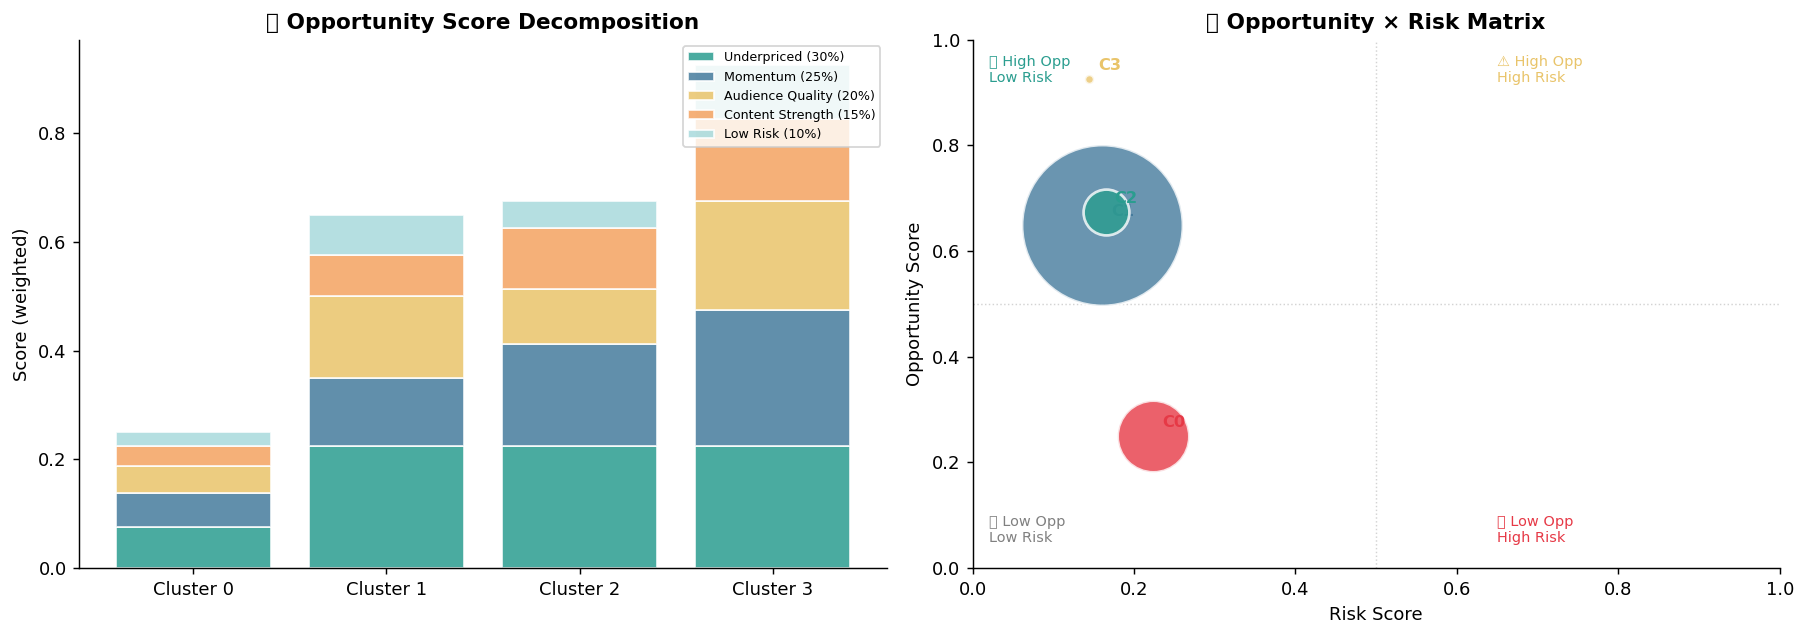

In [35]:
# ============================================================
# 5.4 — OPPORTUNITY SCORING
# Ai đang undervalued với momentum tốt?
# ============================================================

opp_df = pd.DataFrame(index=sorted(df[CLUSTER_COL].unique()))
opp_df.index.name = CLUSTER_COL

# Underpriced signal: recommendRate >> startingRate
opp_df['Underpriced']     = (1 - cluster_med['price_ratio']).clip(lower=0).rank(pct=True)

# Momentum signal: high momentum
opp_df['Momentum']        = momentum_decomp['momentum_final'].rank(pct=True)

# Audience quality signal
opp_df['Audience Quality']= cluster_med['active_active'].rank(pct=True)

# Content strength signal
opp_df['Content Strength']= cluster_med['broadcastingScore'].rank(pct=True)

# Low risk signal
opp_df['Low Risk']         = (1 - risk_df['Overall Risk']).rank(pct=True)

# Composite opportunity score
weights = {'Underpriced': 0.30, 'Momentum': 0.25,
           'Audience Quality': 0.20, 'Content Strength': 0.15, 'Low Risk': 0.10}

opp_df['Opportunity Score'] = sum(
    opp_df[col] * w for col, w in weights.items()
)

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: opportunity component breakdown
ax = axes[0]
comp_names = list(weights.keys())
comp_colors_opp = ['#2A9D8F','#457B9D','#E9C46A','#F4A261','#A8DADC']
x = np.arange(n_clusters)
bottom = np.zeros(n_clusters)
cluster_ids_sorted = sorted(df[CLUSTER_COL].unique())

for col, w, c in zip(comp_names, weights.values(), comp_colors_opp):
    vals = opp_df.loc[cluster_ids_sorted, col].values * w
    ax.bar(x, vals, bottom=bottom, color=c, alpha=0.85, label=f'{col} ({int(w*100)}%)', edgecolor='white')
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels([f'Cluster {i}' for i in cluster_ids_sorted])
ax.set_title('🔎 Opportunity Score Decomposition', fontweight='bold')
ax.set_ylabel('Score (weighted)')
ax.legend(fontsize=7, loc='upper right')

# Right: Opportunity vs Risk 2x2
ax2 = axes[1]
for cid in cluster_ids_sorted:
    x_val = risk_df.loc[cid, 'Overall Risk']
    y_val = opp_df.loc[cid, 'Opportunity Score']
    sz = cluster_sizes[cid] * 2
    color = COLORS[cid]
    ax2.scatter(x_val, y_val, s=sz, color=color, alpha=0.8, edgecolors='white', linewidth=1.5, zorder=3)
    ax2.annotate(f'C{cid}', (x_val, y_val), textcoords='offset points',
                 xytext=(5, 5), fontsize=9, fontweight='bold', color=color)

xm, ym = 0.5, 0.5
ax2.axvline(xm, color='lightgrey', linestyle=':', linewidth=0.8)
ax2.axhline(ym, color='lightgrey', linestyle=':', linewidth=0.8)
ax2.text(0.02, 0.92, '🎯 High Opp\nLow Risk', transform=ax2.transAxes, fontsize=8, color='#2A9D8F')
ax2.text(0.65, 0.92, '⚠️ High Opp\nHigh Risk', transform=ax2.transAxes, fontsize=8, color='#E9C46A')
ax2.text(0.02, 0.05, '💤 Low Opp\nLow Risk',  transform=ax2.transAxes, fontsize=8, color='grey')
ax2.text(0.65, 0.05, '🔴 Low Opp\nHigh Risk', transform=ax2.transAxes, fontsize=8, color='#E63946')

ax2.set_xlabel('Risk Score', fontsize=10)
ax2.set_ylabel('Opportunity Score', fontsize=10)
ax2.set_title('📍 Opportunity × Risk Matrix', fontweight='bold')
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()


██████████████████████████████████████████████████████████████████████
  🎰  FINAL BETTING MATRIX  —  Tổng hợp 3 luồng
██████████████████████████████████████████████████████████████████████

  ┌─ Cluster 0  🎣 Thợ câu view
  │  Audience Gate : 🟡 CAUTION   |   Signal Gate : 🟢 FRESH
  │  Momentum      : 0.494   |   Breakpoint  : ⚪ STABLE
  │  Opportunity   : 0.250   |   Risk        : 0.224
  └→ 👀 WATCH — Insufficient edge

  ┌─ Cluster 1  💎 Viên ngọc ẩn
  │  Audience Gate : 🟢 PASS   |   Signal Gate : 🟢 FRESH
  │  Momentum      : 0.499   |   Breakpoint  : ⚪ STABLE
  │  Opportunity   : 0.650   |   Risk        : 0.160
  └→ ✅ HOLD — Decent value, stable

  ┌─ Cluster 2  💎 Viên ngọc ẩn
  │  Audience Gate : 🟢 PASS   |   Signal Gate : 🟢 FRESH
  │  Momentum      : 0.522   |   Breakpoint  : ⚪ STABLE
  │  Opportunity   : 0.675   |   Risk        : 0.165
  └→ 🏆 BUY NOW — High value, low risk

  ┌─ Cluster 3  💎 Viên ngọc ẩn
  │  Audience Gate : 🟢 PASS   |   Signal Gate : 🟢 FRESH
  │  Momentum      : 0

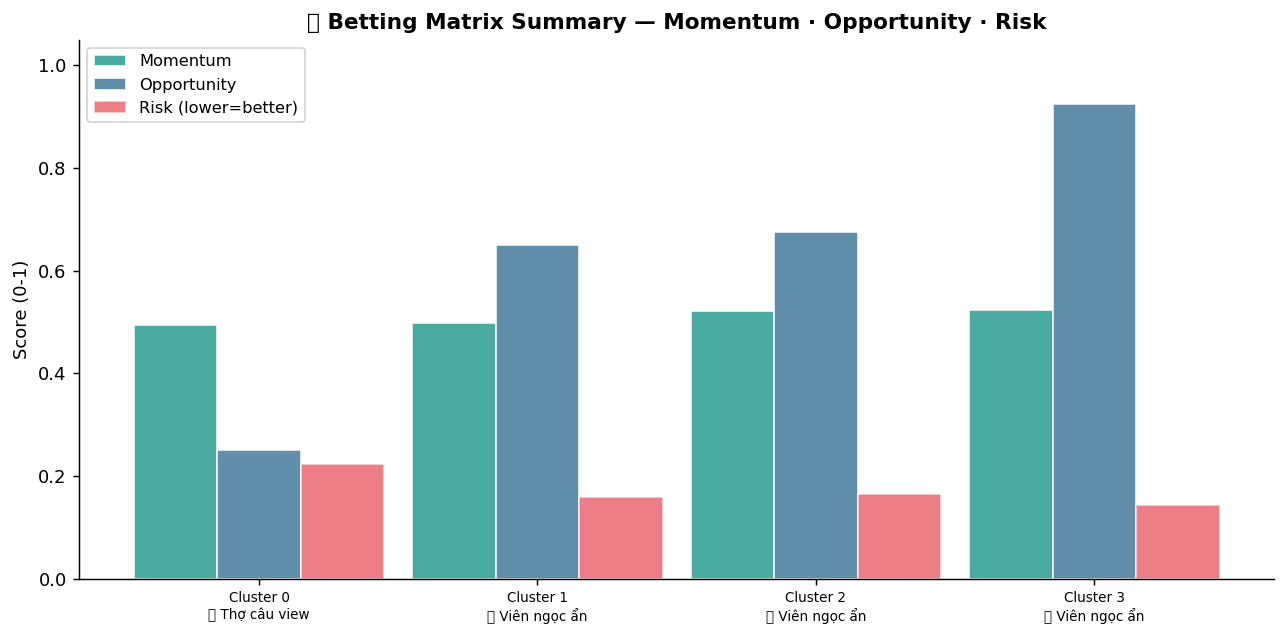


✅ Analysis complete.


In [36]:
# ============================================================
# 5.5 — FINAL BETTING MATRIX
# Tổng hợp 3 luồng → khuyến nghị cuối cùng per cluster
# ============================================================

print('\n' + '█'*70)
print('  🎰  FINAL BETTING MATRIX  —  Tổng hợp 3 luồng')
print('█'*70)

bp_verdict_map = {item['cluster']: item['verdict'] for item in breakpoint_signals}

for cid in sorted(df[CLUSTER_COL].unique()):
    arch     = arch_df.loc[cid, 'archetype'] if cid in arch_df.index else 'N/A'
    f1       = filter1_results[cid]['status']
    f2       = filter2_results[cid]['status']
    momentum = momentum_decomp.loc[cid, 'momentum_final']
    opp      = opp_df.loc[cid, 'Opportunity Score']
    risk     = risk_df.loc[cid, 'Overall Risk']
    bp       = bp_verdict_map.get(cid, '⚪ STABLE')

    # Final verdict
    if '🔴' in f1 or '🔴' in f2:
        verdict = '❌ AVOID — Audience/freshness issues'
    elif opp > 0.65 and risk < 0.45:
        verdict = '🏆 BUY NOW — High value, low risk'
    elif opp > 0.55 and 'ACCELERATING' in bp:
        verdict = '🚀 BUY SOON — Rising momentum'
    elif risk > 0.65:
        verdict = '⚠️ CAUTIOUS — High risk profile'
    elif opp > 0.45 and risk < 0.55:
        verdict = '✅ HOLD — Decent value, stable'
    else:
        verdict = '👀 WATCH — Insufficient edge'

    print(f'\n  ┌─ Cluster {cid}  {arch}')
    print(f'  │  Audience Gate : {f1}   |   Signal Gate : {f2}')
    print(f'  │  Momentum      : {momentum:.3f}   |   Breakpoint  : {bp}')
    print(f'  │  Opportunity   : {opp:.3f}   |   Risk        : {risk:.3f}')
    print(f'  └→ {verdict}')

# ── Summary chart ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

cluster_ids_sorted = sorted(df[CLUSTER_COL].unique())
x = np.arange(len(cluster_ids_sorted))
w = 0.3

ax.bar(x - w, [momentum_decomp.loc[c, 'momentum_final'] for c in cluster_ids_sorted],
       w, label='Momentum', color='#2A9D8F', alpha=0.85, edgecolor='white')
ax.bar(x,     [opp_df.loc[c, 'Opportunity Score'] for c in cluster_ids_sorted],
       w, label='Opportunity', color='#457B9D', alpha=0.85, edgecolor='white')
ax.bar(x + w, [risk_df.loc[c, 'Overall Risk'] for c in cluster_ids_sorted],
       w, label='Risk (lower=better)', color='#E63946', alpha=0.65, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([f'Cluster {c}\n{arch_df.loc[c, "archetype"] if c in arch_df.index else ""}'
                    for c in cluster_ids_sorted], fontsize=7.5)
ax.set_ylabel('Score (0-1)')
ax.set_title('🎯 Betting Matrix Summary — Momentum · Opportunity · Risk', fontweight='bold', fontsize=12)
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

print('\n✅ Analysis complete.')